In [1]:
#logistic svm knn 心臟病 算出accuracy recall roc auc score 哪一個model metrics最好 

import pandas as pd 
import numpy as np

In [3]:
df=pd.read_csv('heart.csv')

In [4]:
df.head(5)
#以下皆為類別變數
#cp: chest pain type 
#fbs(fasting blood sugar > 120 mg/dl) (1 = true; 0 = false) 
#restecg: resting electrocardiographic results 
#exang: exercise induced angina (1 = yes; 0 = no) 
#slope: the slope of the peak exercise ST segment 
#ca: number of major vessels (0-3) colored by flourosopy
#thal: 


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df1=df[['age','trestbps','chol','thalach','oldpeak']] #先將數值型資料做標準化處理

In [9]:
df1

,age,trestbps,chol,thalach,oldpeak
0,63,145,233,150,2.3
1,37,130,250,187,3.5
2,41,130,204,172,1.4
3,56,120,236,178,0.8
4,57,120,354,163,0.6
...,...,...,...,...,...
298,57,140,241,123,0.2
299,45,110,264,132,1.2
300,68,144,193,141,3.4
301,57,130,131,115,1.2


In [21]:
from sklearn.preprocessing import StandardScaler
df1=StandardScaler().fit(df1).transform(df1) #將數值型資料進行標準化

df1
df1=pd.DataFrame(df1)

In [14]:
df1.shape

(303, 5)

In [15]:
df2=df[['cp','fbs','restecg','exang','slope','ca','thal']] #類別型資料

In [16]:
df2=pd.get_dummies(df2,columns=['cp','fbs','restecg','exang','slope','ca','thal'],drop_first=True) #創立虛擬變數

In [17]:
df2

,cp_1,cp_2,cp_3,fbs_1,restecg_1,restecg_2,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0
2,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0
4,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1
299,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1
300,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1
301,0,0,0,0,1,0,1,1,0,1,0,0,0,0,0,1


In [23]:
res = pd.concat([df1,df2],axis=1) #合併data
print(res)

            0         1         2         3         4  cp_1  cp_2  cp_3  \
0    0.952197  0.763956 -0.256334  0.015443  1.087338     0     0     1   
1   -1.915313 -0.092738  0.072199  1.633471  2.122573     0     1     0   
2   -1.474158 -0.092738 -0.816773  0.977514  0.310912     1     0     0   
3    0.180175 -0.663867 -0.198357  1.239897 -0.206705     1     0     0   
4    0.290464 -0.663867  2.082050  0.583939 -0.379244     0     0     0   
..        ...       ...       ...       ...       ...   ...   ...   ...   
298  0.290464  0.478391 -0.101730 -1.165281 -0.724323     0     0     0   
299 -1.033002 -1.234996  0.342756 -0.771706  0.138373     0     0     1   
300  1.503641  0.706843 -1.029353 -0.378132  2.036303     0     0     0   
301  0.290464 -0.092738 -2.227533 -1.515125  0.138373     0     0     0   
302  0.290464 -0.092738 -0.198357  1.064975 -0.896862     1     0     0   

     fbs_1  restecg_1  ...  exang_1  slope_1  slope_2  ca_1  ca_2  ca_3  ca_4  \
0        1        

In [25]:
X=np.array(res)
y=df[['target']] 
y=np.array(y)

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0) #進行train_test_split 0.3 0.7劃分

In [29]:
#model loading
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
lr=LogisticRegression() 
neigh = KNeighborsClassifier(n_neighbors=3)
clf = SVC(gamma='auto')


In [30]:
#開始train data
neigh.fit(X_train,y_train) 


lr.fit(X_train,y_train);

clf.fit(X, y)

/Users/lilinghung/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)
/Users/lilinghung/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:179: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/lilinghung/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


SVC(gamma='auto')

In [33]:
y_pred=lr.predict(X_test)#
y_pred2=neigh.predict(X_test) 
y_pred3=clf.predict(X_test)

In [35]:
from sklearn.metrics import confusion_matrix , plot_confusion_matrix
from sklearn.metrics import recall_score,precision_score,f1_score,accuracy_score

In [39]:
#logistic 表現
print('logistic recall:',recall_score(y_test,y_pred))
print('logistic presicion',precision_score(y_test,y_pred))
print('logistic f1',f1_score(y_test,y_pred))
print('logistic acurracy',accuracy_score(y_test,y_pred))

logistic recall: 0.8936170212765957
logistic presicion 0.7924528301886793
logistic f1 0.8400000000000001
logistic acurracy 0.8241758241758241


In [40]:
#knn 表現
print('knn recall:',recall_score(y_test,y_pred2))
print('knn presicion',precision_score(y_test,y_pred2))
print('knn f1',f1_score(y_test,y_pred2))
print('knn acurracy',accuracy_score(y_test,y_pred2))

knn recall: 0.8297872340425532
knn presicion 0.7222222222222222
knn f1 0.7722772277227723
knn acurracy 0.7472527472527473


In [41]:
#svm 表現
print('svm recall:',recall_score(y_test,y_pred3))
print('svm presicion',precision_score(y_test,y_pred3))
print('svm f1',f1_score(y_test,y_pred3))
print('svm acurracy',accuracy_score(y_test,y_pred3))

svm recall: 0.9148936170212766
svm presicion 0.8431372549019608
svm f1 0.8775510204081632
svm acurracy 0.8681318681318682


In [42]:
from sklearn.metrics import plot_roc_curve

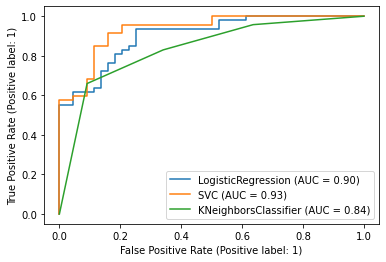

In [44]:
disp=plot_roc_curve(lr,X_test,y_test)            # plot roc curve
plot_roc_curve(clf,X_test,y_test,ax=disp.ax_);    # 
plot_roc_curve(neigh,X_test,y_test,ax=disp.ax_);  #logistic auc=0.9 svc=0.93最好 knn=0.84最糟

In [ ]:
#precision是最好的衡量指標,在預測有心臟病的情況下再繼續做下一步篩檢，才不會浪費醫療資源 ,SVC表現最好